# 1️. Import Libraries and Setup Environment

In [2]:
pip install tensorflow numpy matplotlib seaborn scikit-learn opencv-python pillow streamlit

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip install tensorflow



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# System Libraries
import os
import numpy as np
import warnings

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Image Processing
import cv2
from PIL import Image


# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Evaluation Metrics
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from tensorflow.keras import layers
from tensorflow.keras import models

In [5]:
print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [6]:
from sklearn.model_selection import train_test_split

### Check GPU Availability

In [7]:
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available: 0


### Set Random Seeds

In [8]:
import random

seed = 42

np.random.seed(seed)
tf.random.set_seed(seed)
random.seed(seed)

### Define Global Project Variables

In [9]:
IMG_SIZE = 100
BATCH_SIZE = 32
EPOCHS = 15
DATASET_PATH = "dataset"

### Verify Matplotlib is Working
This confirms that the visualization environment is configured correctly.

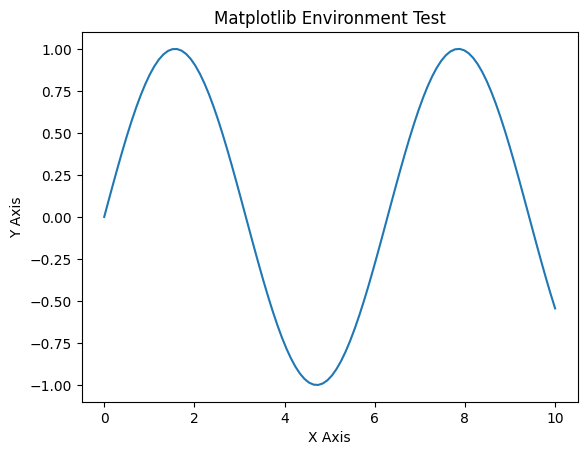

In [10]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, 10, 100)
y = np.sin(x)

plt.plot(x, y)
plt.title("Matplotlib Environment Test")
plt.xlabel("X Axis")
plt.ylabel("Y Axis")
plt.show()

### Verify OpenCV Image Display

Since your project deals with images, it's good to confirm OpenCV works.

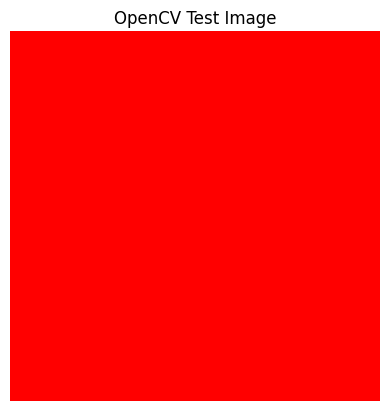

In [11]:
import cv2
import matplotlib.pyplot as plt

img = np.zeros((200,200,3), dtype=np.uint8)

img[:] = [255,0,0]

plt.imshow(img)
plt.title("OpenCV Test Image")
plt.axis("off")
plt.show()

### TensorFlow Device Visualization

This confirms whether the system is using CPU or GPU.

In [12]:
import tensorflow as tf

devices = tf.config.list_physical_devices()

print("Available Devices:")
for device in devices:
    print(device)

Available Devices:
PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')


# 2. Dataset Loading

### 2.1 Define Dataset Path

In [13]:
DATASET_PATH = "dataset"

REAL_PATH = os.path.join(DATASET_PATH, "real")
FAKE_PATH = os.path.join(DATASET_PATH, "fake")

In [14]:
real_images = os.listdir(REAL_PATH)
fake_images = os.listdir(FAKE_PATH)

print("Real Images:", len(real_images))
print("Fake Images:", len(fake_images))

Real Images: 2000
Fake Images: 2000


### 2.2 Create Dataset Metadata Table

In [15]:
import pandas as pd

data = []

for img in real_images:
    data.append({
        "path": os.path.join(REAL_PATH, img),
        "label": "real"
    })

for img in fake_images:
    data.append({
        "path": os.path.join(FAKE_PATH, img),
        "label": "fake"
    })

df = pd.DataFrame(data)

df.head()

,path,label
0,dataset\real\0000 (10).jpg,real
1,dataset\real\0000 (2).jpg,real
2,dataset\real\0000 (3).jpg,real
3,dataset\real\0000 (4).jpg,real
4,dataset\real\0000 (5).jpg,real


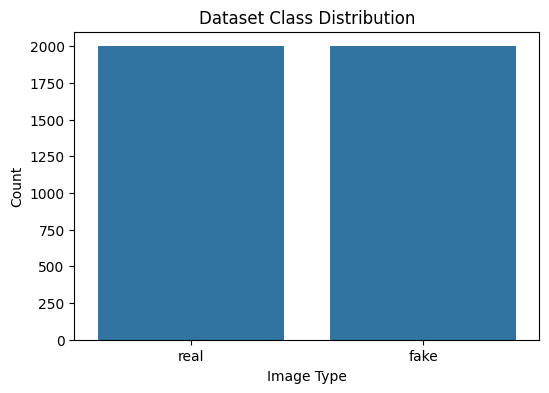

In [16]:
plt.figure(figsize=(6,4))

sns.countplot(x="label", data=df)

plt.title("Dataset Class Distribution")
plt.xlabel("Image Type")
plt.ylabel("Count")

plt.show()

### 2.3 Convert Labels to Numeric

In [17]:
df["label_num"] = df["label"].map({
    "real":0,
    "fake":1
})

In [18]:
df["label"].value_counts()

label
real    2000
fake    2000
Name: count, dtype: int64

### 2.4 Load Images into Memory

In [19]:
IMG_SIZE = 128
images = []
labels = []

In [20]:
for index, row in df.iterrows():
    
    img_path = row["path"]
    label = row["label_num"]
    
    try:
        img = cv2.imread(img_path)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        
        images.append(img)
        labels.append(label)
        
    except:
        pass

In [21]:
X = np.array(images)
y = np.array(labels)

In [22]:
print("Image dataset shape:", X.shape)
print("Labels shape:", y.shape)

Image dataset shape: (4000, 128, 128, 3)
Labels shape: (4000,)


### 2.5 Random Image Samples

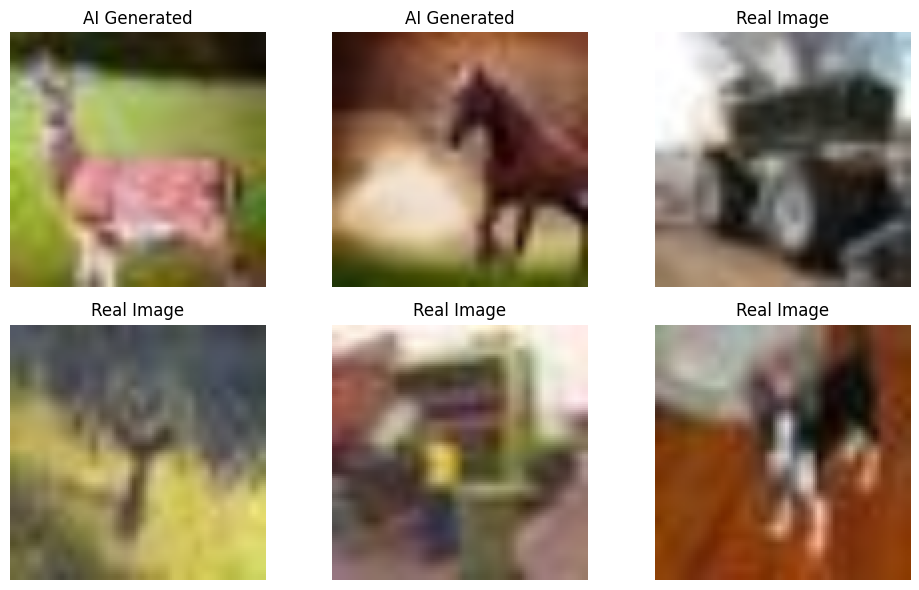

In [23]:
plt.figure(figsize=(10,6))

for i in range(6):

    idx = np.random.randint(0, len(X))

    plt.subplot(2,3,i+1)

    img = X[idx]

    # If image is normalized (0-1), convert for display
    if img.max() <= 1:
        img = img * 255
        img = img.astype("uint8")

    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

    if y[idx] == 0:
        plt.title("Real Image")
    else:
        plt.title("AI Generated")

    plt.axis("off")

plt.tight_layout()
plt.show()

### 2.6 Pixel Distribution

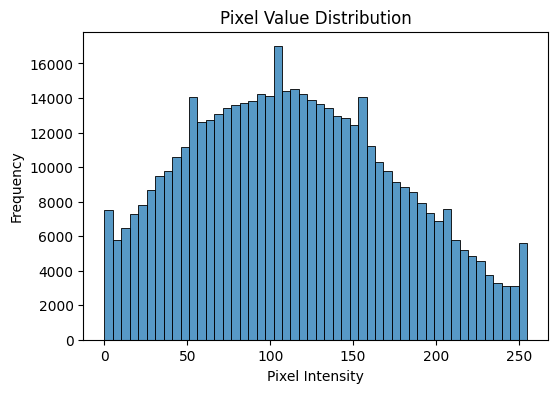

In [24]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Convert datatype (reduce memory)
X = X.astype(np.float32)

# Step 2: Use ravel (no copy) instead of flatten
data = X.ravel()

# Step 3: Sample data (critical for large datasets)
sample_size = min(500000, data.shape[0])
sample = np.random.choice(data, size=sample_size, replace=False)

# Step 4: Plot
plt.figure(figsize=(6,4))
sns.histplot(sample, bins=50)

plt.title("Pixel Value Distribution")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.show()

### 2.7 Dataset Summary

In [25]:
print("Total Images:", len(X))
print("Real Images:", sum(y==0))
print("Fake Images:", sum(y==1))
print("Image Resolution:", X.shape[1:])

Total Images: 4000
Real Images: 2000
Fake Images: 2000
Image Resolution: (128, 128, 3)


# 3.Advanced Exploratory Data Analysis

### 3.1 Dataset Overview
irst we examine the basic statistics of the dataset.

In [26]:
print("Dataset Shape:", X.shape)
print("Labels Shape:", y.shape)

print("Total Images:", len(X))
print("Real Images:", np.sum(y == 0))
print("Fake Images:", np.sum(y == 1))

Dataset Shape: (4000, 128, 128, 3)
Labels Shape: (4000,)
Total Images: 4000
Real Images: 2000
Fake Images: 2000


### 3.2 Class Distribution
Visualize dataset balance.


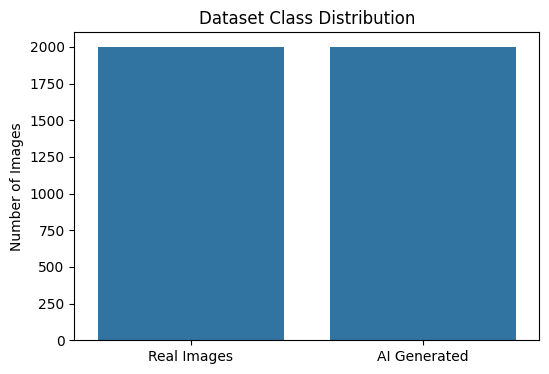

In [27]:
labels = ["Real Images", "AI Generated"]
counts = [len(real_images), len(fake_images)]

plt.figure(figsize=(6,4))
sns.barplot(x=labels, y=counts)
plt.title("Dataset Class Distribution")
plt.ylabel("Number of Images")
plt.show()

### 3.3 Sample Images Visualization

See random samples from each class.

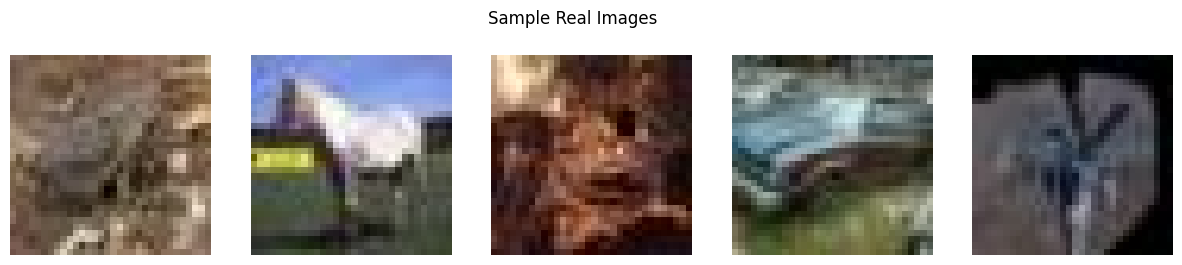

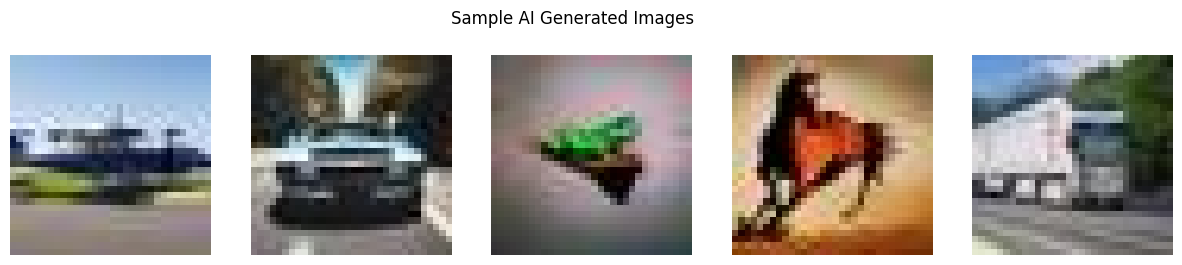

In [28]:
def show_samples(folder, title, n=5):

    images = os.listdir(folder)
    samples = np.random.choice(images, n)

    plt.figure(figsize=(15,3))

    for i,img_name in enumerate(samples):

        img = cv2.imread(os.path.join(folder,img_name))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(1,n,i+1)
        plt.imshow(img)
        plt.axis("off")

    plt.suptitle(title)
    plt.show()

show_samples(REAL_PATH,"Sample Real Images")
show_samples(FAKE_PATH,"Sample AI Generated Images")

### 3.4 Image Size Analysis

Check different image dimensions.

In [29]:
from tqdm import tqdm

In [30]:
widths = []
heights = []

for img_name in tqdm(real_images[:500]):

    img = cv2.imread(os.path.join(REAL_PATH,img_name))

    if img is not None:
        h,w,_ = img.shape
        heights.append(h)
        widths.append(w)

for img_name in tqdm(fake_images[:500]):

    img = cv2.imread(os.path.join(FAKE_PATH,img_name))

    if img is not None:
        h,w,_ = img.shape
        heights.append(h)
        widths.append(w)

100%|██████████| 500/500 [00:00<00:00, 2393.22it/s]


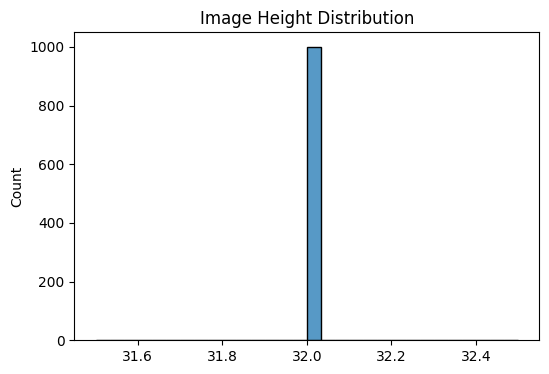

In [31]:
plt.figure(figsize=(6,4))
sns.histplot(heights,bins=30)
plt.title("Image Height Distribution")
plt.show()

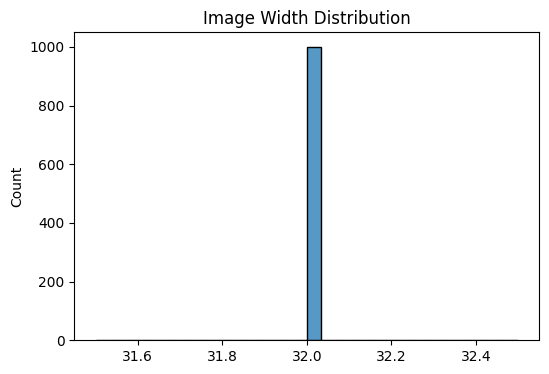

In [32]:
plt.figure(figsize=(6,4))
sns.histplot(widths,bins=30)
plt.title("Image Width Distribution")
plt.show()

### 3.5 Pixel Intensity Distribution

Analyze grayscale pixel patterns.

In [33]:
def pixel_distribution(folder):

    pixels = []

    images = os.listdir(folder)[:200]

    for img_name in images:

        img = cv2.imread(os.path.join(folder,img_name))

        if img is not None:

            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            pixels.extend(gray.flatten())

    return pixels

real_pixels = pixel_distribution(REAL_PATH)
fake_pixels = pixel_distribution(FAKE_PATH)

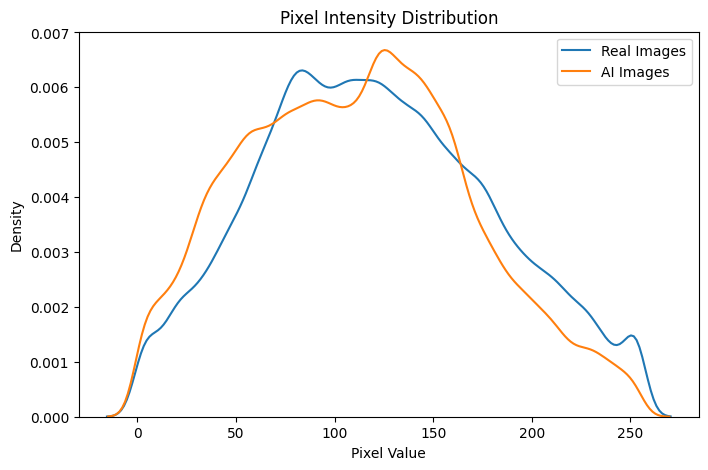

In [34]:
plt.figure(figsize=(8,5))

sns.kdeplot(real_pixels,label="Real Images")
sns.kdeplot(fake_pixels,label="AI Images")

plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.legend()

plt.show()

### 3.6 RGB Channel Analysis

Analyze color channel distribution.

In [35]:
import numpy as np
import cv2
import os

def rgb_distribution(folder):
    r, g, b = [], [], []

    images = os.listdir(folder)[:200]

    for img_name in images:
        img = cv2.imread(os.path.join(folder, img_name))

        if img is not None:
            img = cv2.resize(img, (224,224))
            b_ch, g_ch, r_ch = cv2.split(img)

            # Use ravel (no copy) instead of flatten
            r.append(r_ch.ravel())
            g.append(g_ch.ravel())
            b.append(b_ch.ravel())

    # Convert to single NumPy arrays (much more efficient)
    r = np.concatenate(r).astype(np.float32)
    g = np.concatenate(g).astype(np.float32)
    b = np.concatenate(b).astype(np.float32)

    return r, g, b

r, g, b = rgb_distribution(REAL_PATH)

### 3.7 Average Image Visualization

Compute average image for each class.

In [36]:
def average_image(folder):

    images = os.listdir(folder)[:200]

    avg = None

    for img_name in images:

        img = cv2.imread(os.path.join(folder,img_name))
        img = cv2.resize(img,(224,224))

        if avg is None:
            avg = img.astype("float")
        else:
            avg += img

    avg = avg / len(images)

    return avg.astype("uint8")

avg_real = average_image(REAL_PATH)
avg_fake = average_image(FAKE_PATH)

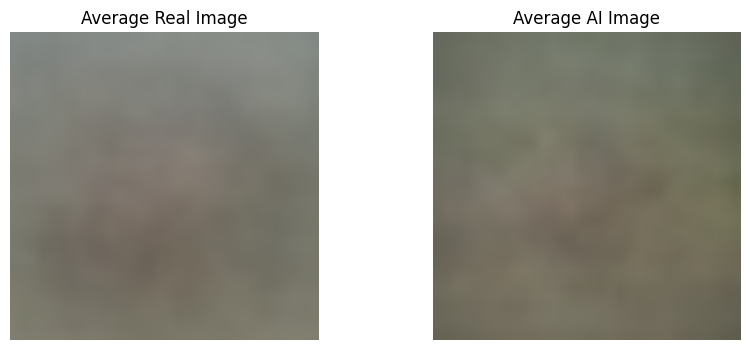

In [37]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(avg_real,cv2.COLOR_BGR2RGB))
plt.title("Average Real Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(avg_fake,cv2.COLOR_BGR2RGB))
plt.title("Average AI Image")
plt.axis("off")

plt.show()

### 3.8 Edge Detection

Use Canny edge detection.

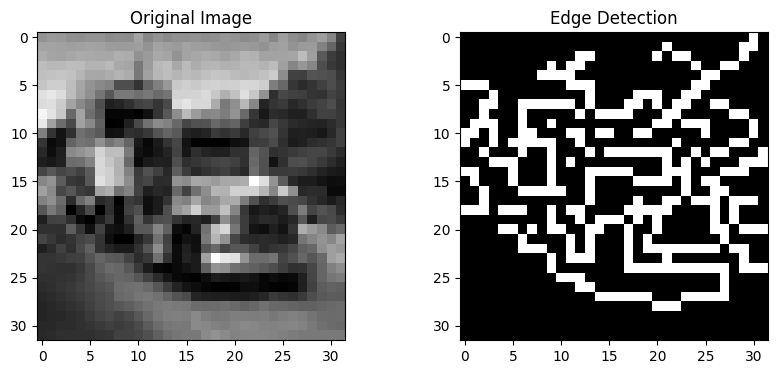

In [38]:
img = cv2.imread(os.path.join(FAKE_PATH,fake_images[0]))
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

edges = cv2.Canny(gray,100,200)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(gray,cmap="gray")
plt.title("Original Image")

plt.subplot(1,2,2)
plt.imshow(edges,cmap="gray")
plt.title("Edge Detection")

plt.show()

### 3.9 Noise Pattern Analysis

Real camera images contain sensor noise.

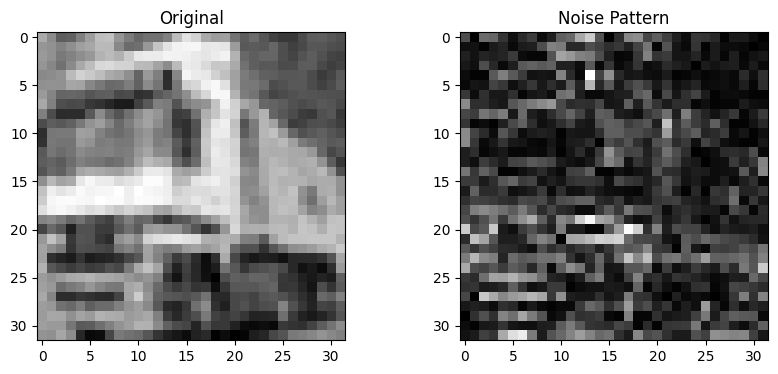

In [39]:
img = cv2.imread(os.path.join(REAL_PATH,real_images[0]))

gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

blur = cv2.GaussianBlur(gray,(5,5),0)

noise = cv2.absdiff(gray,blur)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(gray,cmap="gray")
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(noise,cmap="gray")
plt.title("Noise Pattern")

plt.show()

### 3.10 Frequency Domain Analysis (Advanced)

AI images often show artifacts in frequency space.

In [40]:
img = cv2.imread(os.path.join(FAKE_PATH,fake_images[0]))

gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

f = np.fft.fft2(gray)

fshift = np.fft.fftshift(f)

magnitude = 20*np.log(np.abs(fshift)+1)

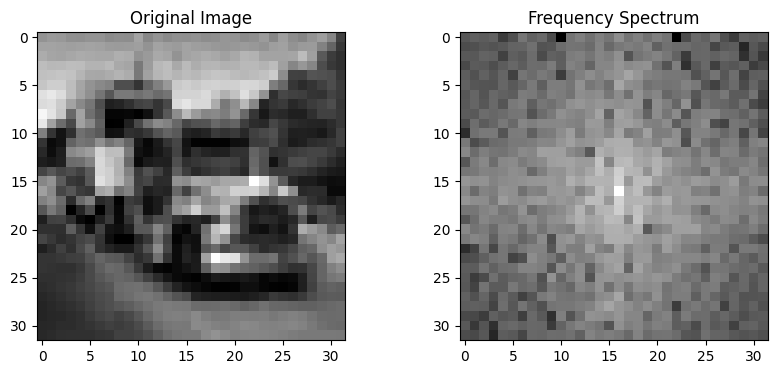

In [41]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(gray,cmap="gray")
plt.title("Original Image")

plt.subplot(1,2,2)
plt.imshow(magnitude,cmap="gray")
plt.title("Frequency Spectrum")

plt.show()

# 4. Advanced Data Preprocessing

### 4.1 Data Validation (Very Important in Industry)

Before training, always verify dataset integrity.

In [42]:
corrupted = []

for path in df["path"]:
    try:
        img = cv2.imread(path)
        if img is None:
            corrupted.append(path)
    except:
        corrupted.append(path)

print("Corrupted images:", len(corrupted))

Corrupted images: 0


In [43]:
df = df[~df["path"].isin(corrupted)]

### 4.2 Image Size Analysis

Real datasets often contain different resolutions.

In [44]:
widths = []
heights = []

for path in df["path"][:500]:

    img = cv2.imread(path)

    if img is not None:
        h, w = img.shape[:2]

        widths.append(w)
        heights.append(h)

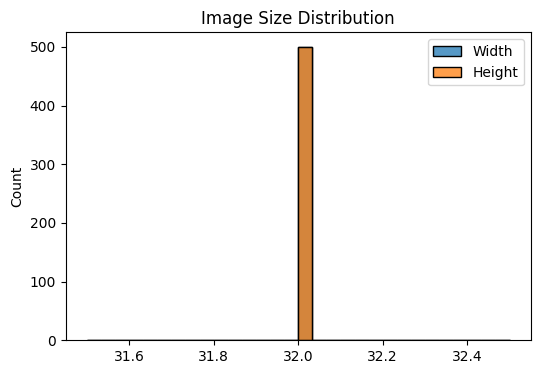

In [45]:
plt.figure(figsize=(6,4))

sns.histplot(widths, bins=30, label="Width")
sns.histplot(heights, bins=30, label="Height")

plt.legend()
plt.title("Image Size Distribution")

plt.show()

### 4.3 Image Resizing & Loading

Instead of simple loops, create a clean loading function.

In [46]:
IMG_SIZE = 224

def load_image(path):

    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    return img

In [47]:
images = []
labels = []

for _, row in df.iterrows():

    img = load_image(row["path"])

    images.append(img)
    labels.append(row["label_num"])

X = np.array(images)
y = np.array(labels)

### 4.4 Normalization vs Standardization

In [48]:
X = X.astype("float32") / 255.0

In [49]:
mean = np.mean(X)
std = np.std(X)

X = (X - mean) / std

### 4.5 Advanced Dataset Splitting

Instead of only train/test, industry uses:

In [50]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

In [51]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

In [52]:
print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (2800, 224, 224, 3)
Validation set: (600, 224, 224, 3)
Test set: (600, 224, 224, 3)


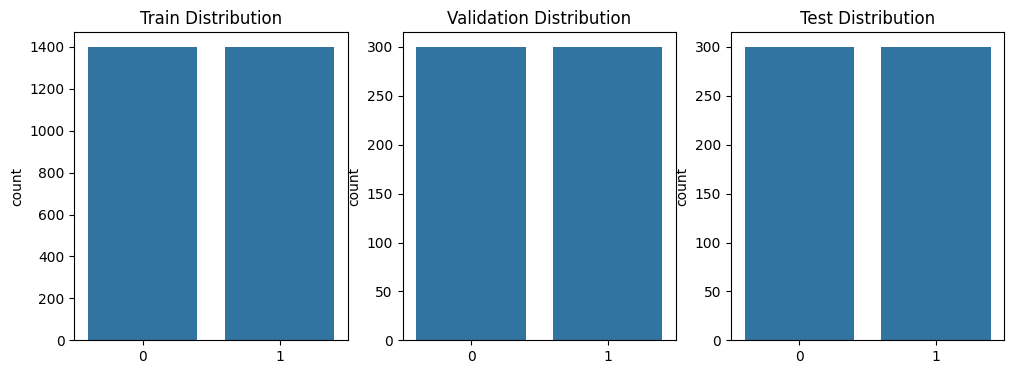

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
sns.countplot(x=y_train)
plt.title("Train Distribution")

plt.subplot(1,3,2)
sns.countplot(x=y_val)
plt.title("Validation Distribution")

plt.subplot(1,3,3)
sns.countplot(x=y_test)
plt.title("Test Distribution")

plt.show()

### 4.6 Advanced Data Augmentation

Industry systems use stronger augmentation.

In [54]:
data_augmentation = tf.keras.Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.15),

    layers.RandomZoom(0.2),

    layers.RandomContrast(0.1),

    layers.RandomBrightness(0.1),

])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [25.277735..27.720413].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [6.1967626..8.549187].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [16.751562..19.223843].


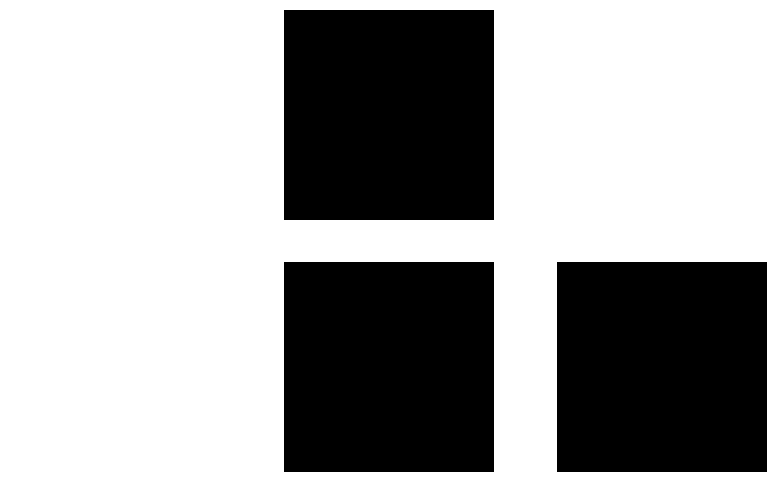

In [55]:
plt.figure(figsize=(10,6))

for i in range(6):

    augmented = data_augmentation(X_train[i:i+1])

    plt.subplot(2,3,i+1)

    plt.imshow(augmented[0])

    plt.axis("off")

plt.show()

### 4.8 Efficient Data Pipeline (tf.data)

Large datasets should not be loaded into memory inefficiently.

In [56]:
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val))
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test))

In [57]:
BATCH_SIZE = 32

train_dataset = train_dataset.shuffle(1000).batch(BATCH_SIZE)
val_dataset = val_dataset.batch(BATCH_SIZE)
test_dataset = test_dataset.batch(BATCH_SIZE)

### 4.9 Prefetching (Industry Optimization)

Prefetching improves training throughput.

In [58]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)

### 4.10 Class Balance Verification

Even though CIFAKE is balanced, always verify.

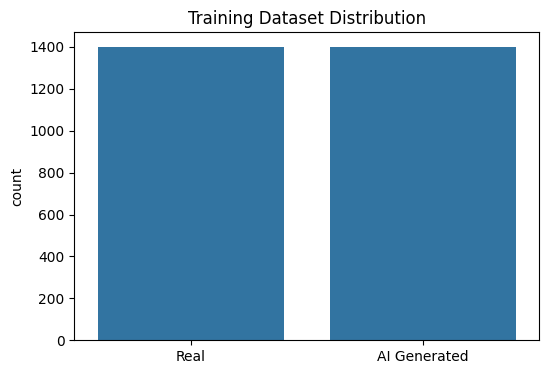

In [59]:
plt.figure(figsize=(6,4))

sns.countplot(x=y_train)

plt.title("Training Dataset Distribution")

plt.xticks([0,1],["Real","AI Generated"])

plt.show()

### 4.11 Data Leakage Check

One important industry practice is ensuring train and test images do not overlap.

In [60]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label_num"],
    random_state=42
)

train_paths = set(train_df["path"])
test_paths = set(test_df["path"])

intersection = train_paths.intersection(test_paths)

print("Duplicate images:", len(intersection))

Duplicate images: 0


# 5.Model Architecture

In [61]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

### 5.1 Load Pretrained EfficientNet

We load EfficientNet without its top classification layer.

In [62]:
base_model = EfficientNetB0(

    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)

)

### 5.2 Freeze Base Model (Important)

Initially we freeze the pretrained layers and This prevents destroying pretrained knowledge.

In [63]:
for layer in base_model.layers:
    layer.trainable = False

### 5.3 Build Custom Classification Head

Now we add our own layers.

In [64]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = BatchNormalization()(x)

x = Dense(128, activation='relu')(x)

x = Dropout(0.5)(x)

output = Dense(1, activation='sigmoid')(x)

### 5.4 Create Final Model

In [65]:
model = Model(inputs=base_model.input, outputs=output)

In [66]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,218,788 (16.09 MB)

 Trainable params: 166,657 (651.00 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

### 5.5 Compile the Model

Now we define the training configuration.

In [67]:
model.compile(

    optimizer=Adam(learning_rate=0.0001),

    loss='binary_crossentropy',

    metrics=['accuracy']

)

# 6.Train the Model

### 6.1 Early Stopping

In [68]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(

    monitor='val_loss',
    patience=5,
    restore_best_weights=True

)

### 6.2 Model Checkpoint

In [69]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(

    "best_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1

)

### 6.3 Reduce Learning Rate

In [70]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(

    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6

)

### 6.4 Start Model Training

In [72]:
history = model.fit(

    train_dataset,

    validation_data=val_dataset,

    epochs=15,
     callbacks=[
        early_stop,
        checkpoint,
        reduce_lr
     ]
)

Epoch 1/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6619 - loss: 0.6058
Epoch 1: val_accuracy did not improve from 0.73667
88/88 ━━━━━━━━━━━━━━━━━━━━ 117s 1s/step - accuracy: 0.6621 - loss: 0.6053 - val_accuracy: 0.7350 - val_loss: 0.5770 - learning_rate: 1.0000e-04
Epoch 2/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 945ms/step - accuracy: 0.6843 - loss: 0.5917
Epoch 2: val_accuracy did not improve from 0.73667
88/88 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - accuracy: 0.6846 - loss: 0.5894 - val_accuracy: 0.7367 - val_loss: 0.5674 - learning_rate: 1.0000e-04
Epoch 3/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 961ms/step - accuracy: 0.6729 - loss: 0.5935
Epoch 3: val_accuracy improved from 0.73667 to 0.73833, saving model to best_model.h5


88/88 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step - accuracy: 0.6743 - loss: 0.5964 - val_accuracy: 0.7383 - val_loss: 0.5665 - learning_rate: 1.0000e-04
Epoch 4/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6631 - loss: 0.6024
Epoch 4: val_accuracy did not improve from 0.73833
88/88 ━━━━━━━━━━━━━━━━━━━━ 121s 1s/step - accuracy: 0.6704 - loss: 0.5984 - val_accuracy: 0.7367 - val_loss: 0.5593 - learning_rate: 1.0000e-04
Epoch 5/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6949 - loss: 0.5933
Epoch 5: val_accuracy improved from 0.73833 to 0.74000, saving model to best_model.h5


88/88 ━━━━━━━━━━━━━━━━━━━━ 126s 1s/step - accuracy: 0.6900 - loss: 0.5874 - val_accuracy: 0.7400 - val_loss: 0.5586 - learning_rate: 1.0000e-04
Epoch 6/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6756 - loss: 0.5883
Epoch 6: val_accuracy improved from 0.74000 to 0.74167, saving model to best_model.h5


88/88 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - accuracy: 0.6832 - loss: 0.5861 - val_accuracy: 0.7417 - val_loss: 0.5579 - learning_rate: 1.0000e-04
Epoch 7/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6904 - loss: 0.5875
Epoch 7: val_accuracy did not improve from 0.74167
88/88 ━━━━━━━━━━━━━━━━━━━━ 131s 1s/step - accuracy: 0.7061 - loss: 0.5754 - val_accuracy: 0.7383 - val_loss: 0.5590 - learning_rate: 1.0000e-04
Epoch 8/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6882 - loss: 0.5767
Epoch 8: val_accuracy did not improve from 0.74167
88/88 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.6864 - loss: 0.5752 - val_accuracy: 0.7300 - val_loss: 0.5568 - learning_rate: 1.0000e-04
Epoch 9/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6713 - loss: 0.5871
Epoch 9: val_accuracy did not improve from 0.74167
88/88 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.6829 - loss: 0.5848 - val_accuracy: 0.6983 - val_loss: 0.5619 - learning_rate: 1.0000e-04
Epoch 10/15
88/88 ━━━━

88/88 ━━━━━━━━━━━━━━━━━━━━ 147s 2s/step - accuracy: 0.6954 - loss: 0.5705 - val_accuracy: 0.7433 - val_loss: 0.5520 - learning_rate: 1.0000e-04
Epoch 11/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6841 - loss: 0.5776
Epoch 11: val_accuracy did not improve from 0.74333
88/88 ━━━━━━━━━━━━━━━━━━━━ 122s 1s/step - accuracy: 0.6871 - loss: 0.5718 - val_accuracy: 0.7050 - val_loss: 0.5557 - learning_rate: 1.0000e-04
Epoch 12/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6954 - loss: 0.5661
Epoch 12: val_accuracy did not improve from 0.74333
88/88 ━━━━━━━━━━━━━━━━━━━━ 111s 1s/step - accuracy: 0.6889 - loss: 0.5745 - val_accuracy: 0.7317 - val_loss: 0.5475 - learning_rate: 1.0000e-04
Epoch 13/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7000 - loss: 0.5694
Epoch 13: val_accuracy did not improve from 0.74333
88/88 ━━━━━━━━━━━━━━━━━━━━ 112s 1s/step - accuracy: 0.6936 - loss: 0.5651 - val_accuracy: 0.7083 - val_loss: 0.5494 - learning_rate: 1.0000e-04
Epoch 14/15
88/8

### 6.5 Fine-Tuning (For Even Higher Accuracy)

After initial training, we unfreeze top layers.

In [73]:
for layer in base_model.layers[-30:]:
    layer.trainable = True

In [74]:
model.compile(

    optimizer=Adam(learning_rate=1e-5),

    loss='binary_crossentropy',

    metrics=['accuracy']

)

In [75]:
history = model.fit(

    train_dataset,
    validation_data=val_dataset,

    epochs=10,

)

Epoch 1/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 163s 2s/step - accuracy: 0.5396 - loss: 0.9494 - val_accuracy: 0.5017 - val_loss: 1.7397
Epoch 2/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 171s 2s/step - accuracy: 0.5675 - loss: 0.8403 - val_accuracy: 0.5017 - val_loss: 2.2559
Epoch 3/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 173s 2s/step - accuracy: 0.5886 - loss: 0.7800 - val_accuracy: 0.5017 - val_loss: 2.1944
Epoch 4/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 161s 2s/step - accuracy: 0.6004 - loss: 0.7609 - val_accuracy: 0.5050 - val_loss: 1.9071
Epoch 5/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 165s 2s/step - accuracy: 0.6200 - loss: 0.7204 - val_accuracy: 0.5150 - val_loss: 1.2422
Epoch 6/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 164s 2s/step - accuracy: 0.6389 - loss: 0.6991 - val_accuracy: 0.5233 - val_loss: 0.9650
Epoch 7/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 155s 2s/step - accuracy: 0.6454 - loss: 0.6859 - val_accuracy: 0.5467 - val_loss: 0.8485
Epoch 8/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 146s 2s/step - accuracy: 0.6546 - loss: 0.6760 - val_accuracy: 0.5750 - v

### 6.8 Training Visualization

Plot training accuracy.

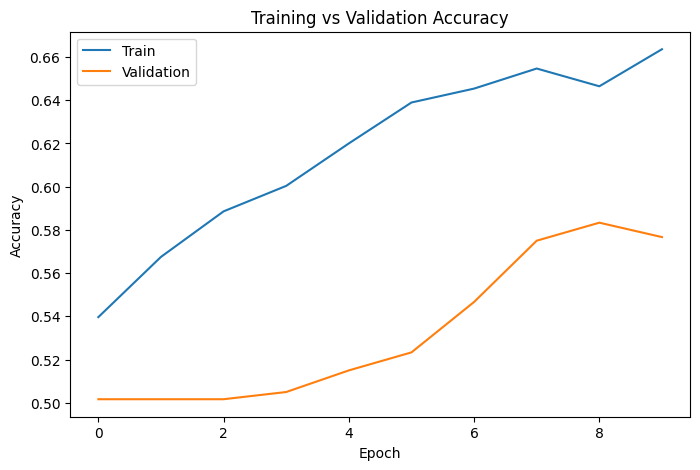

In [76]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Training vs Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.show()

### 6.9 Save the Model

After training:

In [77]:
model.save("best_model.h5")

# 7. Model Evaluation

### 7.1 Evaluate Model on Test Dataset
This gives overall performance metrics.

In [79]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

19/19 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.5833 - loss: 0.7702
Test Loss: 0.7701839208602905
Test Accuracy: 0.5833333134651184


### 7.2 Predict Labels for Test Images

Before creating visualizations, we generate predictions.

In [80]:
y_pred = model.predict(X_test)

y_pred = (y_pred > 0.5).astype(int)

19/19 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step


### 7.3 Confusion Matrix (Most Important Visualization)

Confusion matrix shows detailed classification results.

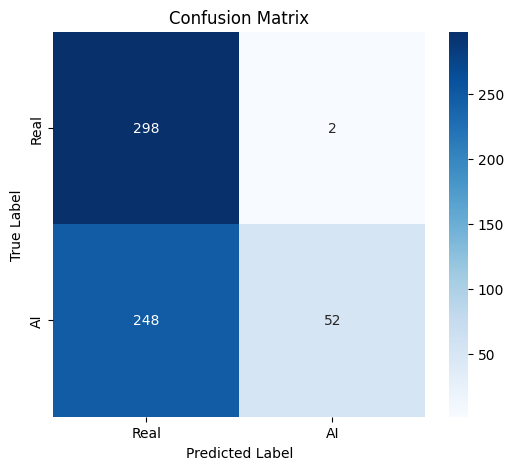

In [81]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["Real","AI"],
            yticklabels=["Real","AI"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

### 7.4 Classification Report

This shows precision, recall, and F1-score.

In [82]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.55      0.99      0.70       300
           1       0.96      0.17      0.29       300

    accuracy                           0.58       600
   macro avg       0.75      0.58      0.50       600
weighted avg       0.75      0.58      0.50       600



### 7.5 ROC Curve Visualization

ROC curve shows classification performance across thresholds.

19/19 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step


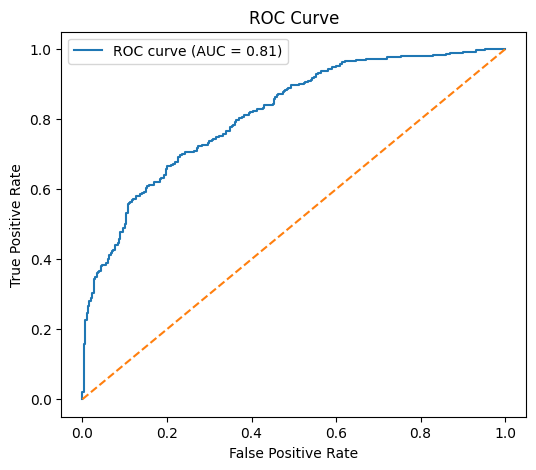

In [83]:
from sklearn.metrics import roc_curve, auc

y_pred_prob = model.predict(X_test)

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label="ROC curve (AUC = %0.2f)" % roc_auc)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

AUC close to 1 → excellent model

AUC around 0.5 → random guessing

### 7.6 Visualize Predictions on Images

This visualization shows real images with model predictions.

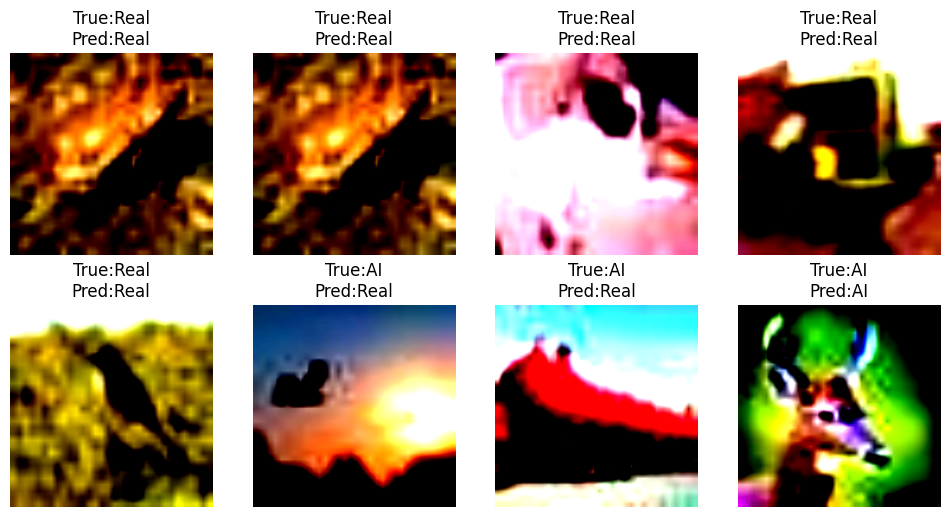

In [85]:
plt.figure(figsize=(12,6))

for i in range(8):

    idx = np.random.randint(0,len(X_test))

    plt.subplot(2,4,i+1)

    plt.imshow(X_test[idx])

    if y_pred[idx] == 0:
        pred_label = "Real"
    else:
        pred_label = "AI"

    true_label = "Real" if y_test[idx]==0 else "AI"

    plt.title(f"True:{true_label}\nPred:{pred_label}")

    plt.axis("off")

plt.show()

### 7.7 Accuracy Distribution Visualization

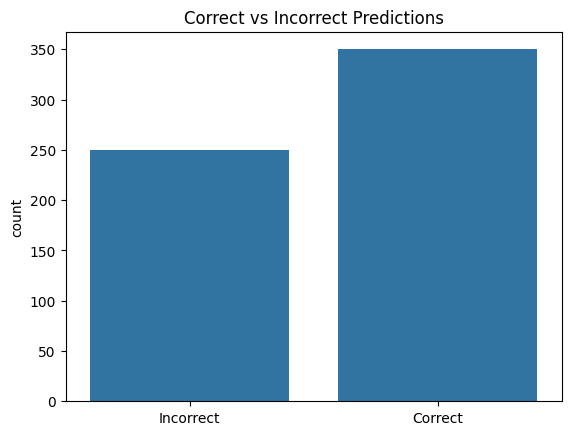

In [86]:
results = (y_pred.flatten() == y_test)

sns.countplot(x=results)

plt.title("Correct vs Incorrect Predictions")

plt.xticks([0,1],["Incorrect","Correct"])

plt.show()

# 8. Visualize Training Accuracy & Loss

### 8.1 Training vs Validation Accuracy Graph

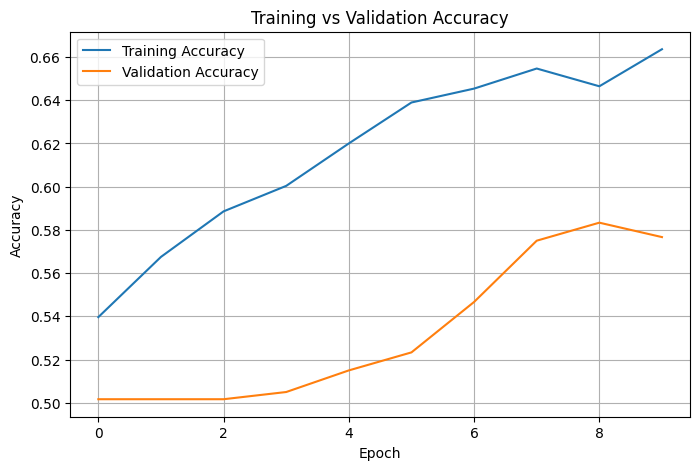

In [87]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label="Training Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.grid()

plt.show()

### 8.2 Training vs Validation Loss Graph

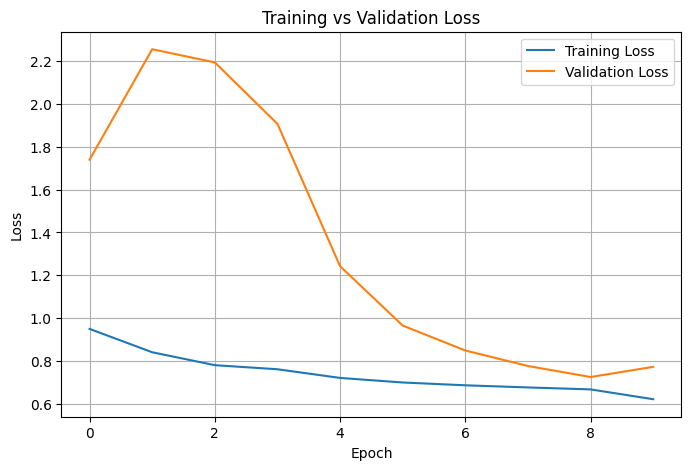

In [88]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label="Training Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")

plt.title("Training vs Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.grid()

plt.show()

### 8.3 Combined Accuracy & Loss Visualization

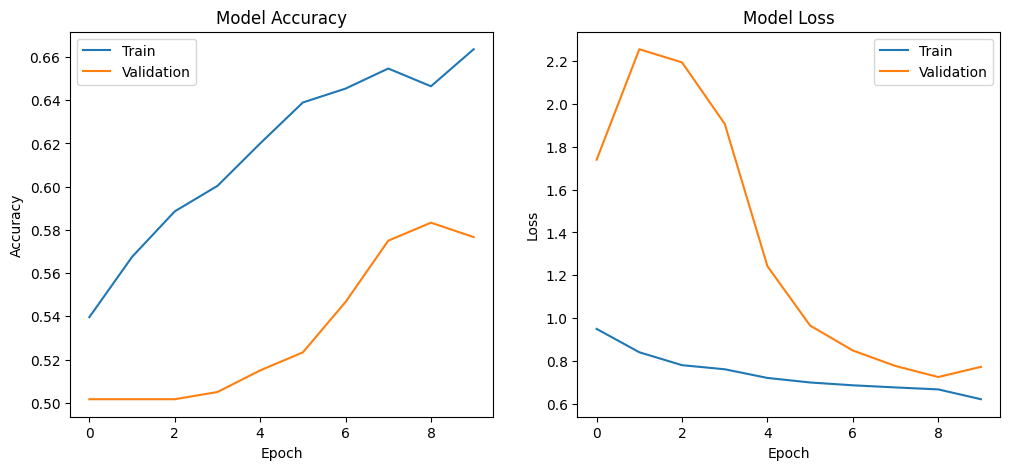

In [89]:
plt.figure(figsize=(12,5))

# Accuracy subplot
plt.subplot(1,2,1)

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])


# Loss subplot
plt.subplot(1,2,2)

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Train","Validation"])

plt.show()

### 8.4 Best Epoch Detection

In [90]:
import numpy as np

best_epoch = np.argmax(history.history['val_accuracy'])

print("Best Epoch:", best_epoch)
print("Best Validation Accuracy:", history.history['val_accuracy'][best_epoch])

Best Epoch: 8
Best Validation Accuracy: 0.5833333134651184


### 8.5 Save Visualization for Report

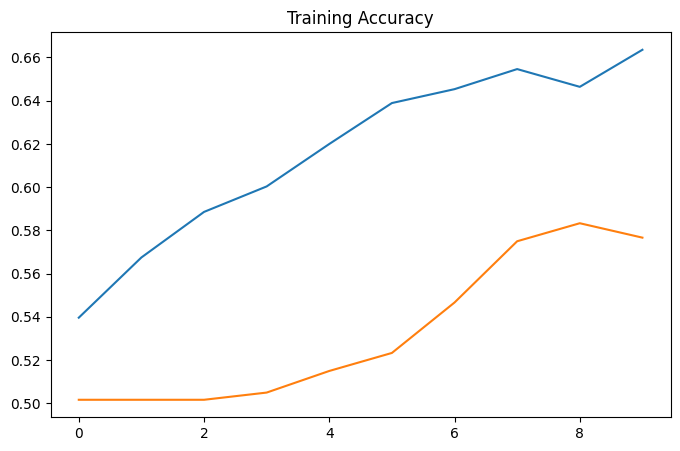

In [91]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Training Accuracy")

plt.savefig("accuracy_plot.png")

plt.show()

# 9. Model Saving

In [92]:
model.save("best_model.h5")

### 9.1 Save Training History

In [93]:
import json

with open("training_history.json", "w") as f:
    json.dump(history.history, f)

In [94]:
with open("training_history.json") as f:
    history = json.load(f)

# 10 Model Prediction on New Images

### 10.1 Loading Saved Model

In [95]:
import tensorflow as tf

model = tf.keras.models.load_model("best_model.h5")

In [96]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,218,790 (16.09 MB)

 Trainable params: 1,662,817 (6.34 MB)

 Non-trainable params: 2,555,971 (9.75 MB)

 Optimizer params: 2 (12.00 B)

### 10.2 Select Random Image

In [97]:
IMG_SIZE = 224

def preprocess_image(image_path):

    img = cv2.imread(image_path)

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    img = img / 255.0

    img = np.expand_dims(img, axis=0)

    return img

In [98]:
def predict_image(image_path):

    img = preprocess_image(image_path)

    prediction = model.predict(img)[0][0]

    confidence = float(prediction)

    if prediction > 0.5:
        label = "AI Generated Image"
        confidence = prediction
    else:
        label = "Real Image"
        confidence = 1 - prediction

    return label, confidence

In [99]:
label, confidence = predict_image(r"C:\Users\Akash\Downloads\Gemini_Generated_Image_9btl7d9btl7d9btl.png")

print("Prediction:", label)
print("Confidence:", round(confidence*100,2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Prediction: Real Image
Confidence: 94.43 %
